# Notebook to generate Cartograms

## 0. Imports

In [1]:
import os
import sys
import numpy as np

project_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(project_dir)

from src.cartograms import *
from src.utils.common import *
from src.tests import *

In [2]:
region, level, year = get_region("netherlands") # world, india, usa, taiwan, netherlands, germany

## 1. DEMERS

Matched name column: 'Entity', value column: 'all years'
Number of unmatched regions for year 2020: 0
Status : optimal
Obj val: 14.7915
12


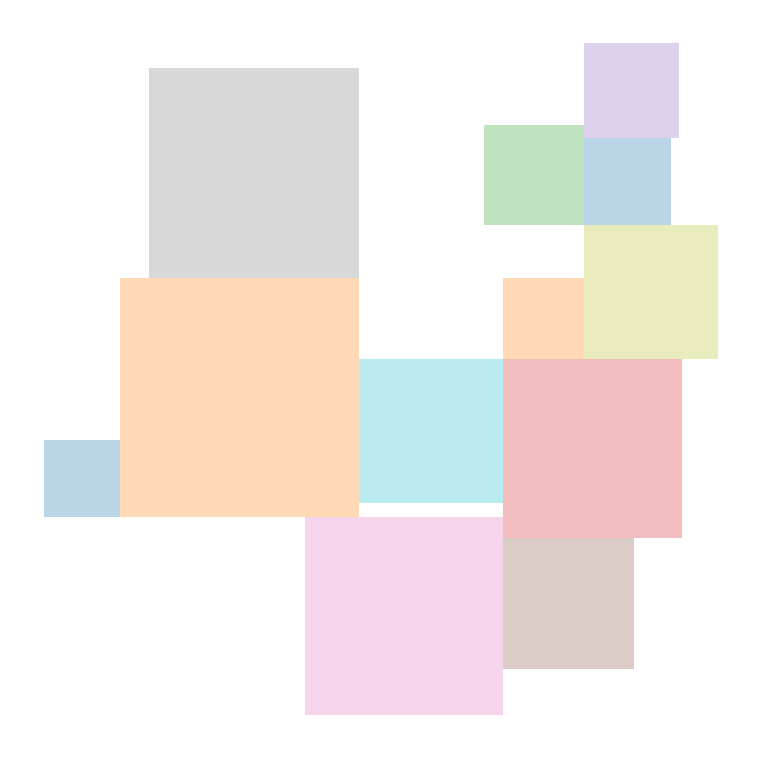

In [3]:
data = demers_cartogram(region, level, year)
print(len(data.keys()))
plot_polys_data(data,  title=f"{region}", centroids=False, legend=False, target_centers=None, svg=True)

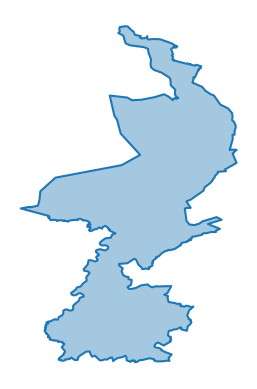

Total area: 5.476491162169623


In [15]:
area = 0
for key in data.keys():
    if key == "Limburg":
        plot_poly(data[key]["polygon"], title="Polygon", label_vertices=False)
    area += data[key]["area"]
print(f"Total area: {area}")

In [5]:
data, dropped = filter_evaluable_regions(data)
quality = quality_criteria(data, cartogram_mode="vertex")
for key in quality.keys():
    print(f"{key}: {quality[key]}")

Mean cartographic error: 1.9498572108810427e-13
Max cartographic error: 4.58116066958725e-13
Mean success rate SR(N): 0.9999999999998782
Topological accuracy: 0.7391304347826086
Mean Hamming distance: 0.3089087446477448
Max Hamming distance: 0.4518959905331872
Mean angular orientation error: 0.2517072579478971
Orthogonal direction error: 0.16666666666666666
Invalid (self-intersecting) polygon count: 0
Overlap area fraction: 1.8359384943301473e-06
Gap area fraction: 1.2618939180717483
Mean vertex count: 4.0


## 2. Dorling

Matched name column: 'Entity', value column: 'all years'
Number of unmatched regions for year 2020: 0
Status : optimal
Obj val: 15.6925
Post-processing: removing residual circle overlap (iterations=300, step=0.5)


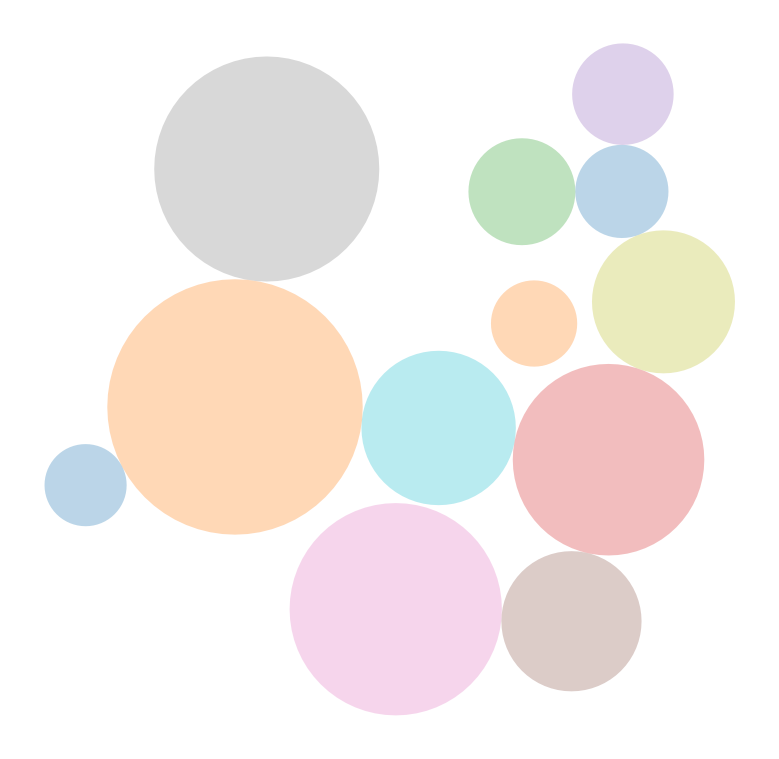

In [6]:
data = dorling_cartogram(region, level, year)
plot_polys_data(data,  title=f"{region}-CFdo", centroids=False, legend=False, target_centers=None, svg=False)

In [7]:
data, dropped = filter_evaluable_regions(data)

quality = quality_criteria(data, cartogram_mode="vertex")
for key in quality.keys():
    print(f"{key}: {quality[key]}")

Mean cartographic error: 1.027268124809155e-09
Max cartographic error: 1.0434039777821564e-09
Mean success rate SR(N): 1.0000000025213858
Topological accuracy: 1.0
Mean Hamming distance: 0.2850203696776474
Max Hamming distance: 0.4196760848162209
Mean angular orientation error: 0.2577490089383977
Orthogonal direction error: 0.16666666666666666
Invalid (self-intersecting) polygon count: 0
Overlap area fraction: 2.7249447047437545e-06
Gap area fraction: 1.1691290806642558
Mean vertex count: 64.0


## 3. Non-Contiguous

In [8]:
data = noncontiguous_cartogram(region, level, year)
# plot_polys_data(data,  title=f"{region}-CFnon", plot_original_outlines=True, centroids=False, legend=False, target_centers=None, svg=False)

Matched name column: 'Entity', value column: 'all years'
Number of unmatched regions for year 2020: 0
  noncontiguous_cartogram: auto area_scale = 0.3830 (worst-case region growth capped at 1.0x its original area)
Status : optimal
Obj val: 0.0592504


In [9]:
data, dropped = filter_evaluable_regions(data)
quality = quality_criteria(data, cartogram_mode="vertex")
for key in quality.keys():
    print(f"{key}: {quality[key]}")

Mean cartographic error: 4.2993024640433555e-06
Max cartographic error: 7.676913338196329e-06
Mean success rate SR(N): 0.9999978477932195
Topological accuracy: 1.0
Mean Hamming distance: 2.827965953345076e-13
Max Hamming distance: 6.704818831040943e-13
Mean angular orientation error: 0.05031283485124852
Orthogonal direction error: 0.015151515151515152
Invalid (self-intersecting) polygon count: 0
Overlap area fraction: 0.0027197116169835446
Gap area fraction: 1.304094642146976
Mean vertex count: 284.0833333333333


## 4. Contiguous

In [10]:
data = contiguous_cartogram(region, level, year,postprocess=True)
# plot_polys_data(data,  title=f"{region}-CF", svg=False)

Matched name column: 'Entity', value column: 'all years'
Number of unmatched regions for year 2020: 0
Status : optimal
Obj val: 411.471


In [11]:
data, dropped = filter_evaluable_regions(data)
quality = quality_criteria(data, cartogram_mode="vertex")
for key in quality.keys():
    print(f"{key}: {quality[key]}")

Mean cartographic error: 0.13270596859887715
Max cartographic error: 0.3933859160398875
Mean success rate SR(N): 1.0278937447269658
Topological accuracy: 0.17391304347826086
Mean Hamming distance: 0.16369502085777407
Max Hamming distance: 0.34370712899281153
Mean angular orientation error: 0.05330667519894113
Orthogonal direction error: 0.015151515151515152
Invalid (self-intersecting) polygon count: 0
Overlap area fraction: 0.0
Gap area fraction: 1.6793173963839099
Mean vertex count: 1267.3333333333333
